In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/athlete_events.csv')
noc = pd.read_csv('data/noc_regions.csv')
df = df.merge(noc[['NOC', 'region']], on='NOC', how='left')
print(f'Loaded {len(df)} rows, {df.shape[1]} columns')

Loaded 271116 rows, 16 columns


# Viz 1: Women's share of Olympic competitors over time

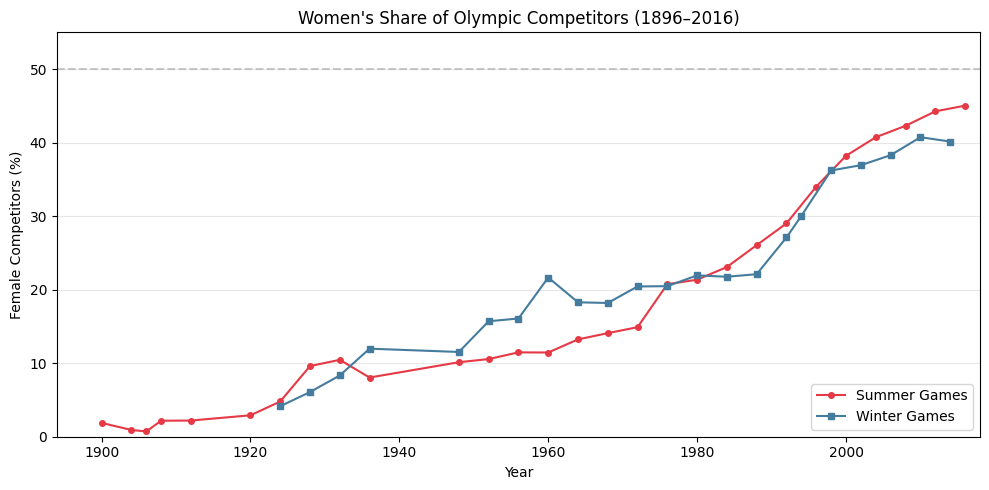

In [2]:

gender = df.groupby(['Year', 'Season', 'Sex'])['ID'].nunique().reset_index(name='count')
total = gender.groupby(['Year', 'Season'])['count'].transform('sum')
gender['pct'] = gender['count'] / total * 100
female = gender[gender['Sex'] == 'F']

summer_f = female[female['Season'] == 'Summer'].sort_values('Year')
winter_f = female[female['Season'] == 'Winter'].sort_values('Year')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(summer_f['Year'], summer_f['pct'], 'o-', color='#E63946', label='Summer Games', markersize=4)
ax.plot(winter_f['Year'], winter_f['pct'], 's-', color='#457B9D', label='Winter Games', markersize=4)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Year')
ax.set_ylabel('Female Competitors (%)')
ax.set_title("Women's Share of Olympic Competitors (1896\u20132016)")
ax.legend()
ax.set_xlim(1894, 2018)
ax.set_ylim(0, 55)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz1_gender_participation.png', dpi=150)
plt.show()

# Viz 2: Home Countries winning medals compared to regular

   Host_Country            City  Year  Season  Host_Year_Medals  \
19       Greece          Athina  1896  Summer              44.0   
17       Greece          Athina  1906  Summer              35.0   
3       Finland        Helsinki  1952  Summer              22.0   
14    Australia       Melbourne  1956  Summer              35.0   
16        Japan           Tokyo  1964  Summer              29.0   
11       Mexico     Mexico City  1968  Summer               9.0   
12      Germany          Munich  1972  Summer             106.0   
15       Canada        Montreal  1976  Summer              11.0   
13  South Korea           Seoul  1988  Summer              33.0   
0         Spain       Barcelona  1992  Summer              22.0   
4     Australia          Sydney  2000  Summer              58.0   
9        Greece          Athina  2004  Summer              16.0   
7         China         Beijing  2008  Summer             100.0   
8        Brazil  Rio de Janeiro  2016  Summer              19.

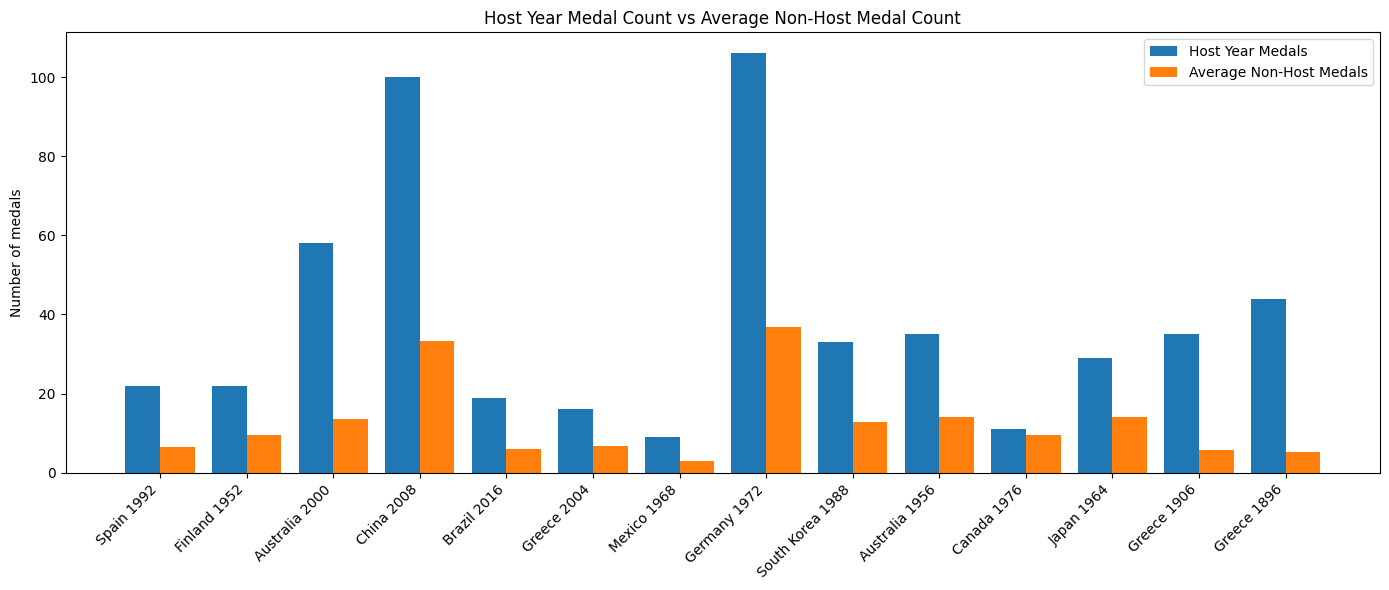

In [11]:
host_country = {
    "Rio de Janeiro": "Brazil",
    "London": "United Kingdom",
    "Beijing": "China",
    "Athina": "Greece",
    "Sydney": "Australia",
    "Atlanta": "United States",
    "Barcelona": "Spain",
    "Seoul": "South Korea",
    "Los Angeles": "United States",
    "Moscow": "Russia",
    "Montreal": "Canada",
    "Munich": "Germany",
    "Mexico City": "Mexico",
    "Tokyo": "Japan",
    "Rome": "Italy",
    "Melbourne": "Australia",
    "Helsinki": "Finland",
    "London": "United Kingdom"
}

df["Host_Country"] = df["City"].map(host_country)
df_medals = df[df["Medal"].notna()].copy()
medals = df_medals.groupby(["Year","NOC"]).size().reset_index(name="Medal_Count")
unique_medals = df_medals.drop_duplicates(
    subset=["Year", "Season", "NOC", "Event", "Medal"]
)
medal_counts = (
    unique_medals
    .groupby(["Year", "Season", "region"], as_index=False)
    .size()
    .rename(columns={"size": "Medal_Count"})
)

hosts = (
    df[["Year", "Season", "City", "Host_Country"]]
    .drop_duplicates()
    .dropna(subset=["Host_Country"])
)

hosts = hosts.drop_duplicates(subset=["Year", "Season"])

host_year_medals = hosts.merge(
    medal_counts,
    left_on=["Year", "Season", "Host_Country"],
    right_on=["Year", "Season", "region"],
    how="left"
)

host_year_medals["Medal_Count"] = host_year_medals["Medal_Count"].fillna(0)

host_year_medals = host_year_medals[["Year", "Season", "City", "Host_Country", "Medal_Count"]].rename(
    columns={"Medal_Count": "Host_Year_Medals"}
)

results = []

for _, row in host_year_medals.iterrows():
    host_year = row["Year"]
    host_season = row["Season"]
    host_country_name = row["Host_Country"]
    host_city = row["City"]
    host_medals = row["Host_Year_Medals"]

    non_host_years = medal_counts[
        (medal_counts["region"] == host_country_name) &
        ~(
            (medal_counts["Year"] == host_year) &
            (medal_counts["Season"] == host_season)
        )
    ]

    avg_non_host = non_host_years["Medal_Count"].mean()

    results.append({
        "Host_Country": host_country_name,
        "City": host_city,
        "Year": host_year,
        "Season": host_season,
        "Host_Year_Medals": host_medals,
        "Avg_Non_Host_Medals": avg_non_host
    })

results_df = pd.DataFrame(results)
results_df = results_df.dropna(subset=["Avg_Non_Host_Medals"])

print(results_df.sort_values(["Year", "Season"]).head(20))

plot_df = results_df.copy()
plot_df["Label"] = plot_df["Host_Country"] + " " + plot_df["Year"].astype(str)

x = range(len(plot_df))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(
    [i - width/2 for i in x],
    plot_df["Host_Year_Medals"],
    width=width,
    label="Host Year Medals"
)
plt.bar(
    [i + width/2 for i in x],
    plot_df["Avg_Non_Host_Medals"],
    width=width,
    label="Average Non-Host Medals"
)

plt.xticks(list(x), plot_df["Label"], rotation=45, ha="right")
plt.ylabel("Number of medals")
plt.title("Host Year Medal Count vs Average Non-Host Medal Count")
plt.legend()
plt.tight_layout()
plt.show()

# Viz 3: How the age distribution of Olympic athletes vary by sport and sex

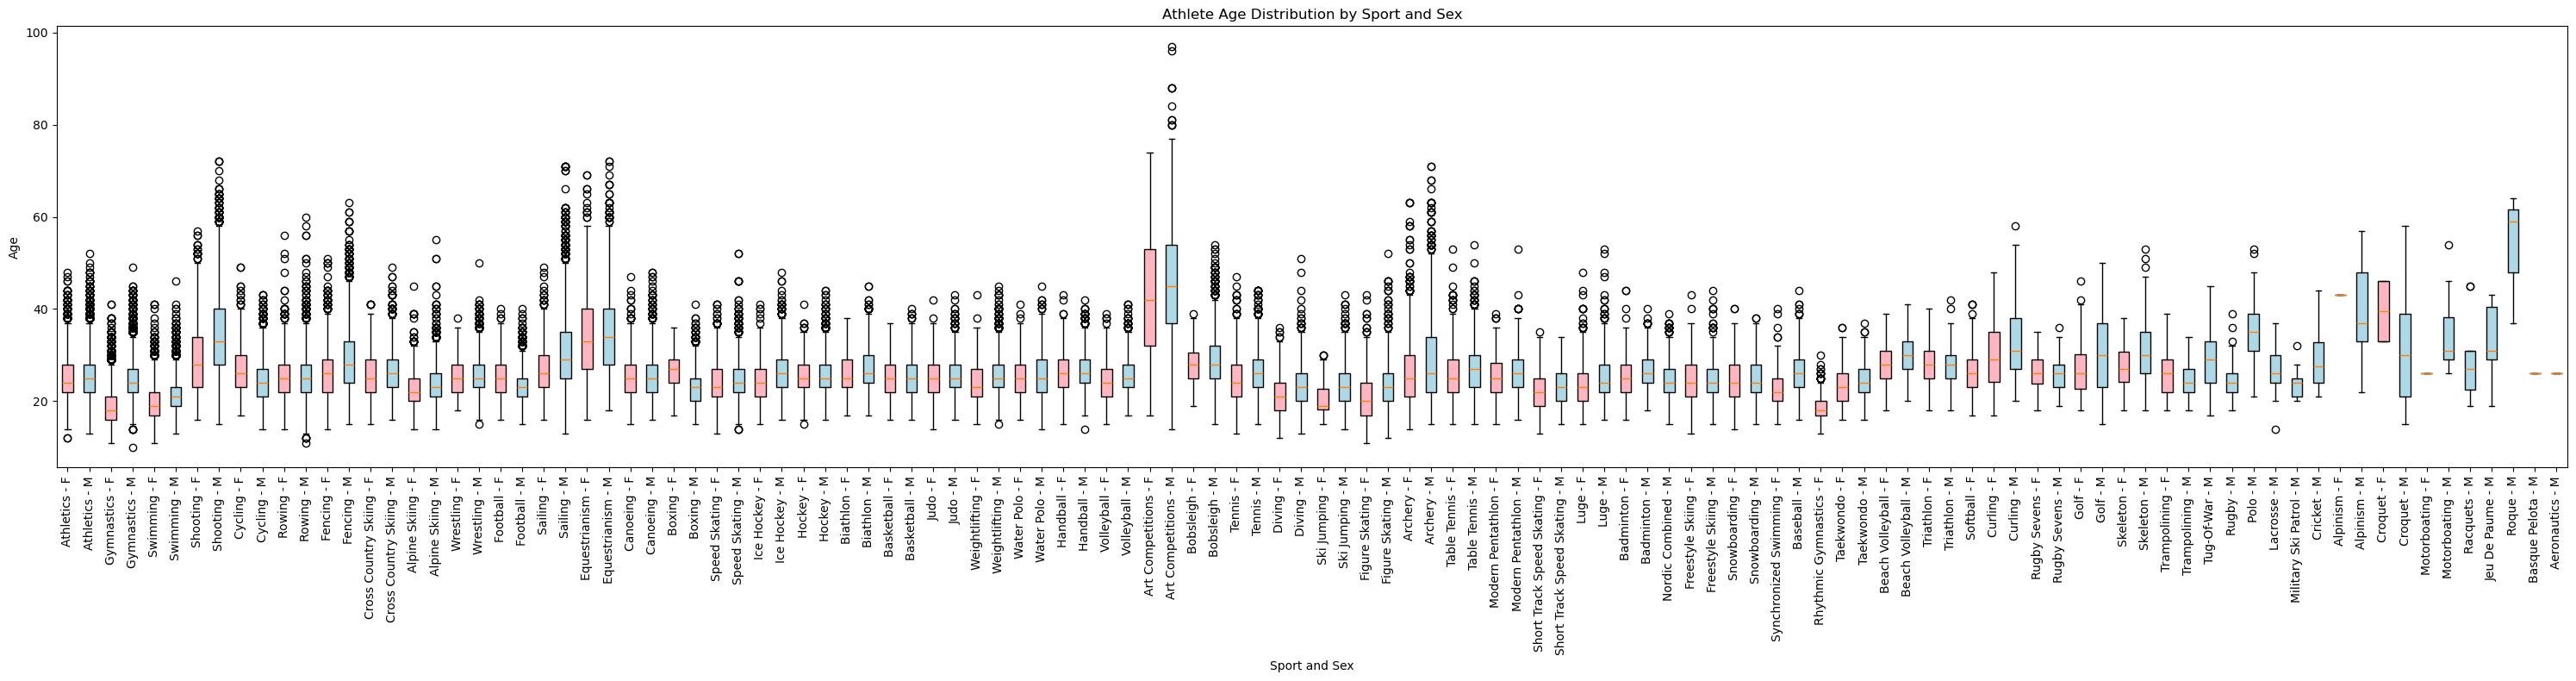

In [15]:
age_df = df[['Sport', 'Sex', 'Age']].dropna()
age_df = age_df[(age_df['Sex'] == 'M') | (age_df['Sex'] == 'F')]

age_df['Sport_Sex'] = age_df['Sport'] + ' - ' + age_df['Sex']

sports = age_df['Sport'].value_counts().index

labels = []
for sport in sports:
    if ((age_df['Sport'] == sport) & (age_df['Sex'] == 'F')).any():
        labels.append(sport + ' - F')
    if ((age_df['Sport'] == sport) & (age_df['Sex'] == 'M')).any():
        labels.append(sport + ' - M')

plot_data = [age_df[age_df['Sport_Sex'] == label]['Age'] for label in labels]

plt.figure(figsize=(30, 8))
bp = plt.boxplot(plot_data, tick_labels=labels, patch_artist=True)

for box, label in zip(bp['boxes'], labels):
    if label.endswith('F'):
        box.set_facecolor('lightpink')
    else:
        box.set_facecolor('lightblue')

plt.xticks(rotation=90)
plt.xlabel('Sport and Sex')
plt.ylabel('Age')
plt.title('Athlete Age Distribution by Sport and Sex')
plt.tight_layout()
plt.show()

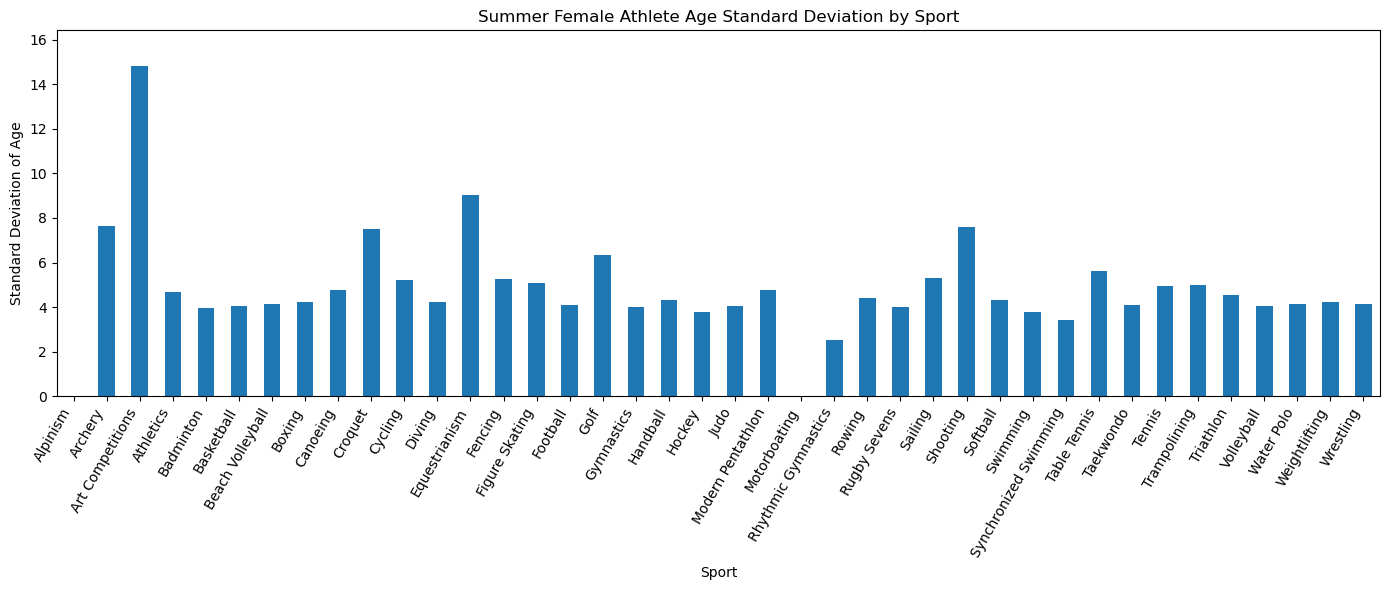

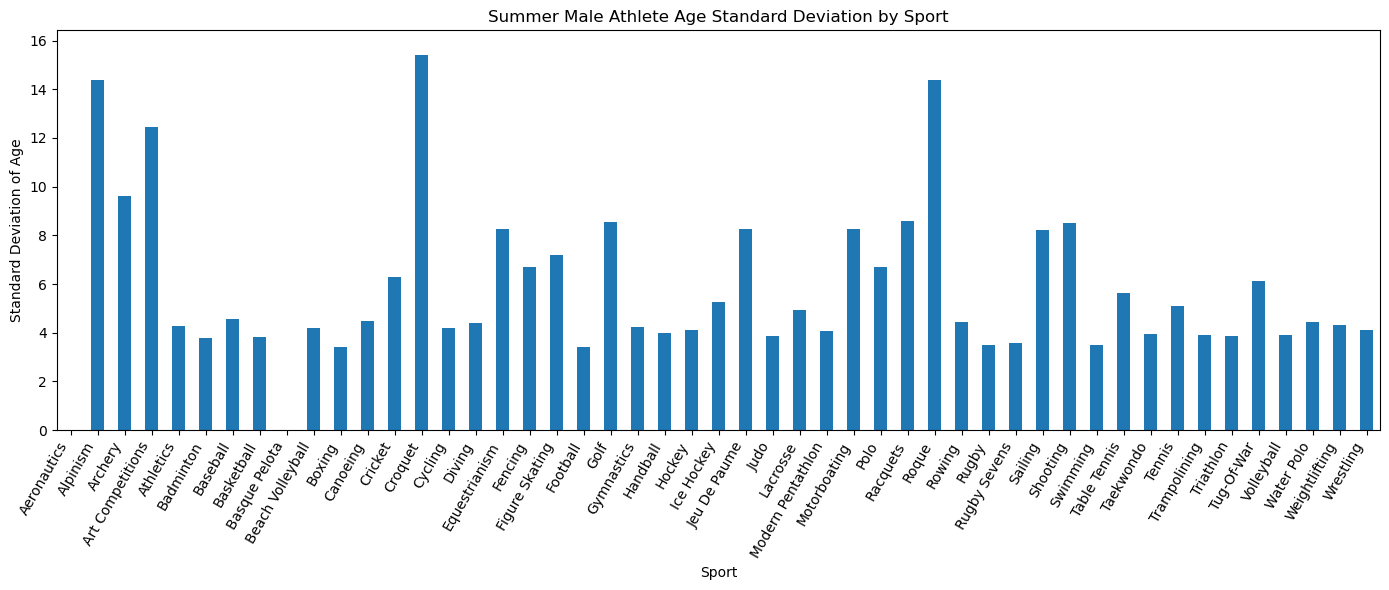

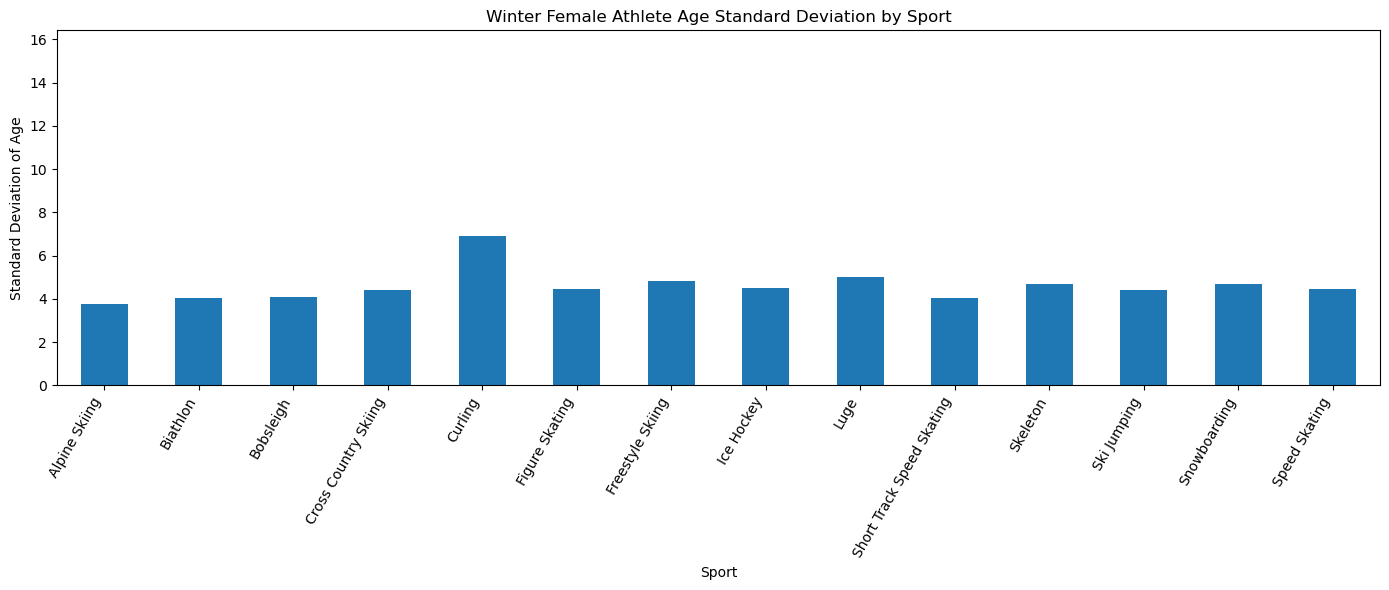

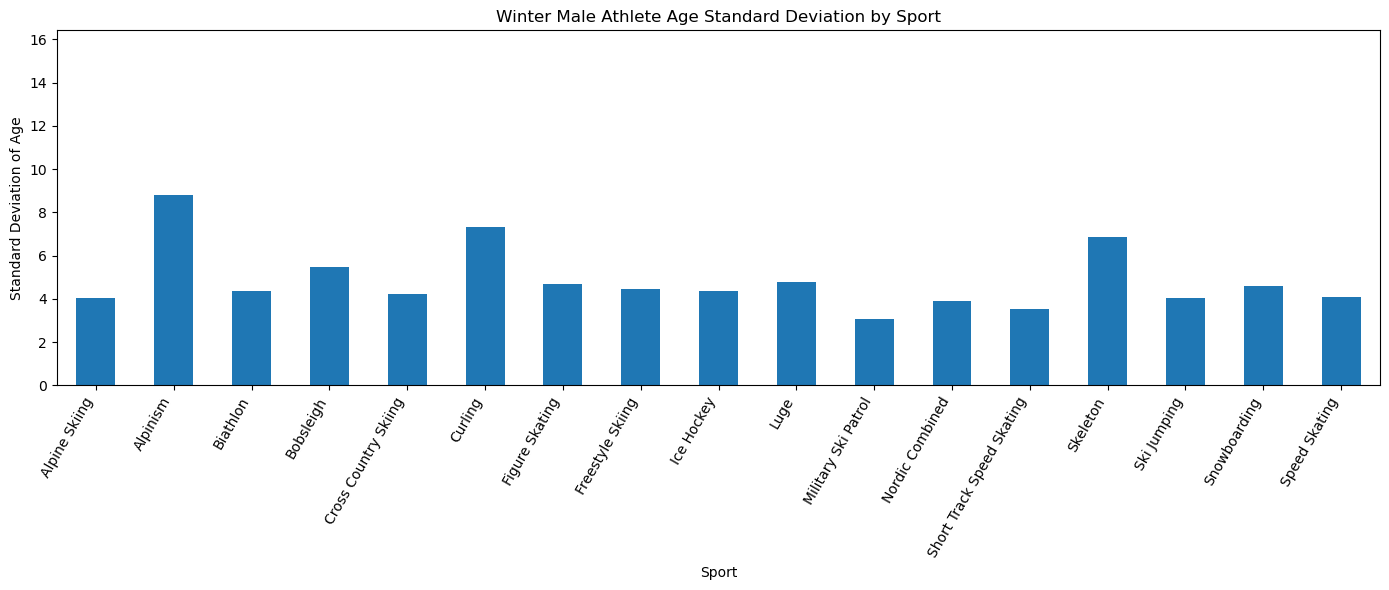

In [ ]:
age_df = df[['Sport', 'Sex', 'Season', 'Age']].dropna()
age_df = age_df[(age_df['Sex'] == 'F') | (age_df['Sex'] == 'M')]

summer_female = age_df[(age_df['Season'] == 'Summer') & (age_df['Sex'] == 'F')]
summer_male = age_df[(age_df['Season'] == 'Summer') & (age_df['Sex'] == 'M')]
winter_female = age_df[(age_df['Season'] == 'Winter') & (age_df['Sex'] == 'F')]
winter_male = age_df[(age_df['Season'] == 'Winter') & (age_df['Sex'] == 'M')]

summer_female_std = summer_female.groupby('Sport')['Age'].std()
summer_male_std = summer_male.groupby('Sport')['Age'].std()
winter_female_std = winter_female.groupby('Sport')['Age'].std()
winter_male_std = winter_male.groupby('Sport')['Age'].std()

max_std = max(
    summer_female_std.max(),
    summer_male_std.max(),
    winter_female_std.max(),
    winter_male_std.max()
)

summer_female_std.plot(kind='bar', figsize=(14, 6))
plt.ylim(0, max_std + 1)
plt.xlabel('Sport')
plt.ylabel('Standard Deviation of Age')
plt.title('Summer Female Athlete Age Standard Deviation by Sport')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

summer_male_std.plot(kind='bar', figsize=(14, 6))
plt.ylim(0, max_std + 1)
plt.xlabel('Sport')
plt.ylabel('Standard Deviation of Age')
plt.title('Summer Male Athlete Age Standard Deviation by Sport')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

winter_female_std.plot(kind='bar', figsize=(14, 6))
plt.ylim(0, max_std + 1)
plt.xlabel('Sport')
plt.ylabel('Standard Deviation of Age')
plt.title('Winter Female Athlete Age Standard Deviation by Sport')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

winter_male_std.plot(kind='bar', figsize=(14, 6))
plt.ylim(0, max_std + 1)
plt.xlabel('Sport')
plt.ylabel('Standard Deviation of Age')
plt.title('Winter Male Athlete Age Standard Deviation by Sport')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

# Viz 4: How summer and winter medal patterns differ for each country

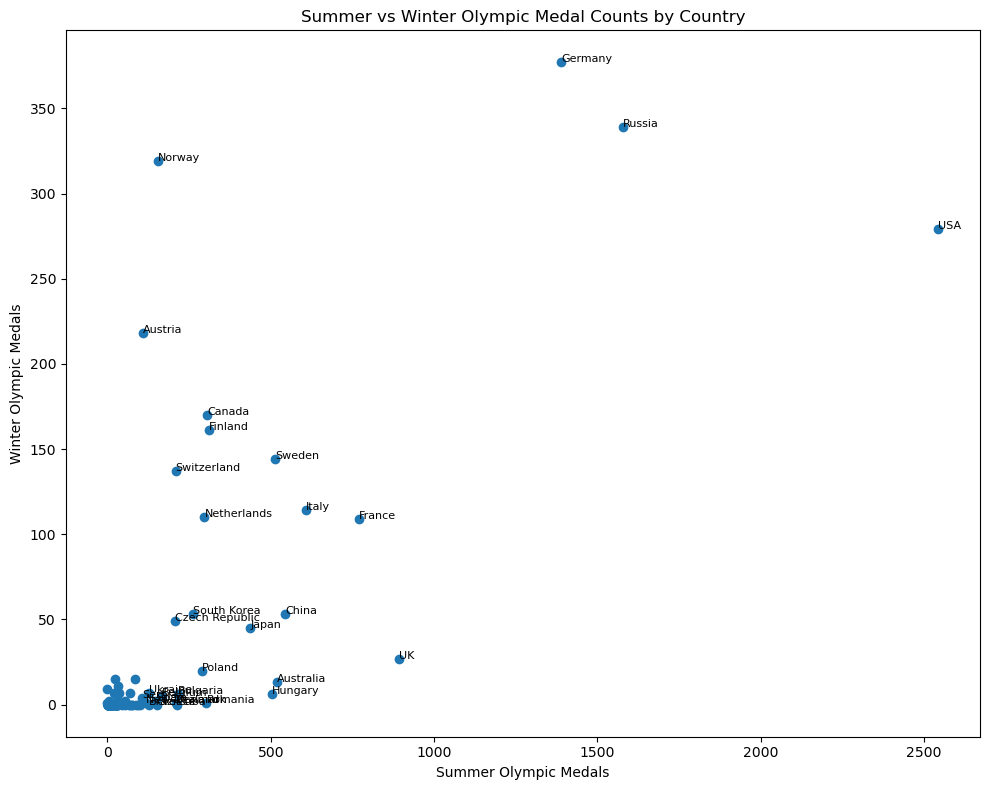

In [18]:
medal_df = df[['region', 'Season', 'Year', 'Event', 'Medal']].dropna()

country_season_medals = (
    medal_df
    .drop_duplicates(subset=['region', 'Season', 'Year', 'Event', 'Medal'])
    .groupby(['region', 'Season'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 8))
plt.scatter(country_season_medals['Summer'], country_season_medals['Winter'])

plt.xlabel('Summer Olympic Medals')
plt.ylabel('Winter Olympic Medals')
plt.title('Summer vs Winter Olympic Medal Counts by Country')

for country in country_season_medals.index:
    x = country_season_medals.loc[country, 'Summer']
    y = country_season_medals.loc[country, 'Winter']
    if x > 100 or y > 40:
        plt.text(x, y, country, fontsize=8)

plt.tight_layout()
plt.show()